https://archive.ics.uci.edu/dataset/579/myocardial+infarction+complications

In [18]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
current_dir = Path.cwd()


In [19]:
# run from the directory "Myocardial-infarction-ML-Project"
#ln -s ../Data_Loading+Metadata/Myocardial_Infarction_Split.parquet \
#      EDA+model_preparation/Myocardial_Infarction_Split.parquet

In [20]:
split_data = pd.read_parquet(
    "Myocardial_Infarction_Split.parquet",
    engine="pyarrow"
)
split_data.head()

,train_dummy,ZSN,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,...,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,REC_IM,P_IM_STEN,LET_IS
0,0,0,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,...,0,0,0,0,0,0,0,0,0,0


### Confirm Outcome Splits for Binary Target Variables

| Variable | Role | Type | Description | Missing Values?|
|---|---|---|---|---|
| FIBR_PREDS | Target | Binary | Atrial fibrillation | no |
| PREDS_TAH | Target | Binary | Supraventricular tachycardia | no |
| JELUD_TAH | Target | Binary | Ventricular tachycardia | no |
| FIBR_JELUD | Target | Binary | Ventricular fibrillation | no |
| A_V_BLOK | Target | Binary | Third-degree AV block | no |
| OTEK_LANC | Target | Binary | Pulmonary edema | no |
| RAZRIV | Target | Binary | Myocardial rupture | no |
| DRESSLER | Target | Binary | Dressler syndrome | no |
| ZSN | Target | Binary | Chronic heart failure | no |
| REC_IM | Target | Binary | Relapse of the myocardial infarction | no |
| P_IM_STEN | Target | Binary | Post-infarction angina | no |

In [21]:
outcome_vars = [
    "FIBR_PREDS", "PREDS_TAH", "JELUD_TAH", "FIBR_JELUD",
    "A_V_BLOK", "OTEK_LANC", "RAZRIV", "DRESSLER",
    "ZSN", "REC_IM", "P_IM_STEN"
]

outcome_split_summary = pd.DataFrame({
    "count_1": split_data[outcome_vars].sum(),
    "count_0": (split_data[outcome_vars] == 0).sum(),
    "proportion_1": split_data[outcome_vars].mean()
}).reset_index().rename(columns={"index": "outcome"})

print(outcome_split_summary)

       outcome  count_1  count_0  proportion_1
0   FIBR_PREDS      170     1530      0.100000
1    PREDS_TAH       20     1680      0.011765
2    JELUD_TAH       42     1658      0.024706
3   FIBR_JELUD       71     1629      0.041765
4     A_V_BLOK       57     1643      0.033529
5    OTEK_LANC      159     1541      0.093529
6       RAZRIV       54     1646      0.031765
7     DRESSLER       75     1625      0.044118
8          ZSN      394     1306      0.231765
9       REC_IM      159     1541      0.093529
10   P_IM_STEN      148     1552      0.087059


This confirms that most of the binary outcome variables are not missing any values, however the proportion of positive cases for each outcome variable is quite low. ZSN offers the highest proportion of positive cases at 32.17% so we decided to prioritize this variable.

NOTE: from papers such as https://pmc.ncbi.nlm.nih.gov/articles/PMC12894713/pdf/41598_2026_Article_36798.pdf

Third-degree (Atrioventricular) AV block seems to be best predicted by the given data, with the Mean AUC for Chronic heart failure (ZSN) performing not too well.

In [22]:
# Drop other binary outcome variables and the Categorical Outcome Variable "LET_IS"

cols_to_drop = list(set(outcome_vars) - {"ZSN"}) + ["LET_IS"]
split_data = split_data.drop(columns=cols_to_drop, errors="ignore")
split_data.shape

(1700, 113)

### General Feature Selection Plan: (informed by additionalcodebook.txt and clinical knowledge)

#### Features were excluded if they:
- Occurred after admission (to avoid temporal leakage)
- Had extreme missingness (>70%)
- Had very low prevalence (<~5% when being mindfull that the dataset isn't very large)
- Represented treatment decisions rather than baseline patient state

#### Discussion of potentially excluded features:
* for example nr_* variables (relating to arrhythmia) have high missingness 
* many anamnesis variables have extremely low prevalence (even if we collapse categories) and are likely not reliably recorded, since much of this dataset consists of patients not suffering from myociardial infarction
    * e.g. some endocr*; np*; nr*; zab_leg* have variables where the positive class is <1% of the dataset

for example the following engineered variable still has extremely low prevalence:
```python
any_conduction_abnormality = (
    (np01 == 1) | (np04 == 1) |
    (np05 == 1) | (np07 == 1) |
    (np08 == 1) | (np09 == 1) |
    (np10 == 1)
)
```

Recoding Less Important Categorical Variables since they have categories with very low prevalence:

```python
has_hypertension = GB > 0
long_duration_htn = DLIT_AG >= 6
```

Collapsing Variables Example:

```python
any_pulmonary_disease = (
    (zab_leg_01 == 1) |
    (zab_leg_02 == 1) |
    (zab_leg_03 == 1)
)
```


### Feature Selection using EDA and Clinical Knowledge

Feature set is informed by previous literature and clinical knowledge. Further feature engineering is done to ensure features are in a format that can be used for modeling.

#### 1. Core Demographic Variables + Stronger Historical Risk Factors:

* age
* sex
* INF_ANAM, STENOK_AN, FK_STENOK, IBS_POST
* GB, DLIT_AG
* ZSN_A
    * Read as: 2 lines of severity (0<1<2<4 & 0<1<3<4) where State 4 means simultaneous states 2 and 3
* diabetes

#### 2. Disease History / Baseline Risk:

* S_AD_ORIT, D_AD_ORIT
* K_SH_POST, O_L_POST
* TIME_B_S
* MP_TP_POST

#### 3. Admission Severity (Acute Presentation) ~ many of these features present infrequently

* Admission severity (~5–6)
* S_AD_ORIT, D_AD_ORIT
* K_SH_POST (shock)
* O_L_POST (pulmonary edema)
* TIME_B_S
~ MP_TP_POST

#### 4. Labs (act as supporting features in this dataset):

* NA_BLOOD, K_BLOOD
* L_BLOOD ~ perhaps recode as high_wbc = (L_BLOOD > 11).astype(int) to capture leukocytosis
* ROE
* ALT_BLOOD, AST_BLOOD ~ highly skewed (log transform)

~ GIPO_K appears to be a binary recoding of K_BLOOD (hyperkalemia)
~ GIPER_NA, KFK_BLOOD have extremely low prevalence of positive cases/high missingness

#### 5. ECG Features (Engineered + Selection ~ choose features that are more reliably recorded and have higher prevalence)

Due to high dimensionality and sparsity, ECG variables were compressed into clinically meaningful groups:

* Infarct location: ant_im, lat_im, inf_im, post_im (perhaps collapse to binary presence)
* Rhythm
* Abnormalities

In [23]:
base_cols = [
    # Targets / split
    "ZSN", "train_dummy",
    # Core
    "AGE", "SEX",

    # History
    "INF_ANAM", "STENOK_AN", "FK_STENOK", "IBS_POST",
    "GB", "DLIT_AG", "ZSN_A", "endocr_01",

    # History ~ deal with by collapsing into one feature
    "zab_leg_01", "zab_leg_02", "zab_leg_03",
        # zab_leg_04 and zab_leg_06 are not indluded due to extremely low pos. prevalence

    # Admission
    "S_AD_ORIT", "D_AD_ORIT",
    "K_SH_POST", "O_L_POST",
    "TIME_B_S", "MP_TP_POST",

    # Labs
    "NA_BLOOD", "K_BLOOD",
    "L_BLOOD", "ROE",
    "ALT_BLOOD", "AST_BLOOD",

    # ECG infarct location
    "ant_im", "lat_im", "inf_im", "post_im",

    # ECG rhythm ~ choose the overarchin rhythm feature (loose some granularity but reduce sparsity)
    "ritm_ecg_p_01",
    # ritm_ecg_p_07 (tachycardia) is also in contention 

    # ECG abnormalities (for collapsing)
    "n_r_ecg_p_01", "n_r_ecg_p_02", "n_r_ecg_p_03", "n_r_ecg_p_04",
    "n_r_ecg_p_05", "n_r_ecg_p_06", "n_r_ecg_p_08",
    "n_p_ecg_p_01", "n_p_ecg_p_03", "n_p_ecg_p_04",
    "n_p_ecg_p_05", "n_p_ecg_p_06", "n_p_ecg_p_07",
    "n_p_ecg_p_08", "n_p_ecg_p_09", "n_p_ecg_p_10",
    "n_p_ecg_p_11", "n_p_ecg_p_12",

    # Variables that would have been included but have low positive prevalence
#    "nr11", "nr03", "nr04",
#    "np01", "np04", "np05", "np07", "np08", "np09", "np10",
#    "endocr_02",
]

In [24]:
# subset split_data to include only base_cols

model_data1 = split_data[base_cols].copy()
model_data1.shape

(1700, 50)

In [25]:
# collapsing features ~ ECG and

def collapse_binary_any(df, cols, new_col):
    df[new_col] = df[cols].eq(1).any(axis=1).astype(int)
    return df.drop(columns=cols)

model_data2 = (
    model_data1
    .copy()
)

model_data2 = collapse_binary_any(
    model_data2,
    ["zab_leg_01", "zab_leg_02", "zab_leg_03"],
    "any_pulmonary_disease"
)

# Arrhythmias
model_data2 = collapse_binary_any(
    model_data2,
    [
        "n_r_ecg_p_01", "n_r_ecg_p_02", "n_r_ecg_p_03", "n_r_ecg_p_04",
        "n_r_ecg_p_05", "n_r_ecg_p_06", "n_r_ecg_p_08"
    ],
    "any_arrhythmia"
)

# Conduction
model_data2 = collapse_binary_any(
    model_data2,
    [
        "n_p_ecg_p_01", "n_p_ecg_p_03", "n_p_ecg_p_04",
        "n_p_ecg_p_05", "n_p_ecg_p_06", "n_p_ecg_p_07",
        "n_p_ecg_p_08", "n_p_ecg_p_09", "n_p_ecg_p_10",
        "n_p_ecg_p_11", "n_p_ecg_p_12"
    ],
    "any_conduction_block"
)
model_data2.shape


(1700, 32)

### Binarization of Location Categorical Variabbles

* ant_im, lat_im, inf_im, post_im
    * 0 = no infarct
    * 1–4 = different QRS morphologies (severity/pattern)
* ordering is not cleanly linear or comparable across patients

In [26]:
model_data3 = model_data2.copy()

for col in ["ant_im", "lat_im", "inf_im", "post_im"]:
    model_data3[col] = (model_data3[col] > 0).astype(int)

### Numerical Variables:

* AGE
* S_AD_ORIT
* D_AD_ORIT
* NA_BLOOD
* K_BLOOD
* L_BLOOD
* ROE
* ALT_BLOOD
* AST_BLOOD

### Ordinal Variables:

* INF_ANAM       # 0,1,2,3+
* STENOK_AN      # time categories
* FK_STENOK      # functional class
* IBS_POST       # disease severity
* GB             # hypertension stage
* DLIT_AG        # duration bins
* ZSN_A          # heart failure severity
* TIME_B_S       # time-to-hospital bins

### Binary Variables

* SEX
* endocr_01 (diabetes)
* K_SH_POST
* O_L_POST
* MP_TP_POST

ant_im, lat_im, inf_im, post_im   # after binarization

* any_pulmonary_disease
* any_arrhythmia
* any_conduction_block

```python
df["early_presentation"] = (df["TIME_B_S"] <= 3).astype(int)
df["late_presentation"] = (df["TIME_B_S"] >= 7).astype(int)
```
* early_presentation / late_presentation (if TIME_B_S does not perform well)

## EDA for Numerical Variables

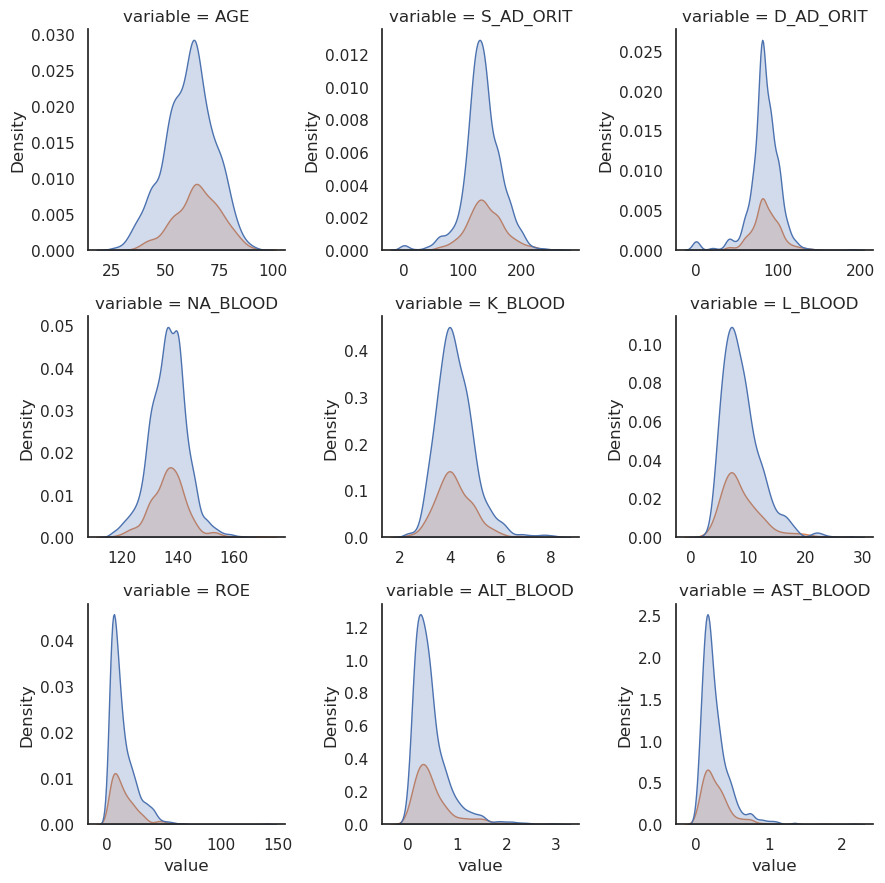

In [27]:
# Look at Distrubtions for laboratory values that are known to be subject to skewed distributions

sns.set_theme(style="white")

num_cols = [
    "AGE", "S_AD_ORIT", "D_AD_ORIT",
    "NA_BLOOD", "K_BLOOD",
    "L_BLOOD", "ROE",
    "ALT_BLOOD", "AST_BLOOD"
]

df_long = model_data2[num_cols + ["ZSN"]].melt(
    id_vars="ZSN",
    var_name="variable",
    value_name="value"
)

g = sns.FacetGrid(df_long, col="variable", col_wrap=3, sharex=False, sharey=False)
g.map_dataframe(sns.kdeplot, x="value", hue="ZSN", fill=True)

plt.show()

The results suggest that log transformations for AST_BLOOD, ALT_BLOOD and ROE may be beneficial to reduce skewness and improve model performance.

In [28]:
log_cols = ["ROE", "ALT_BLOOD", "AST_BLOOD"]

for col in log_cols:
    model_data3[col + "_log"] = np.log1p(model_data3[col])

# drop original columns after log transformation
model_data3 = model_data3.drop(columns=log_cols, errors="ignore")


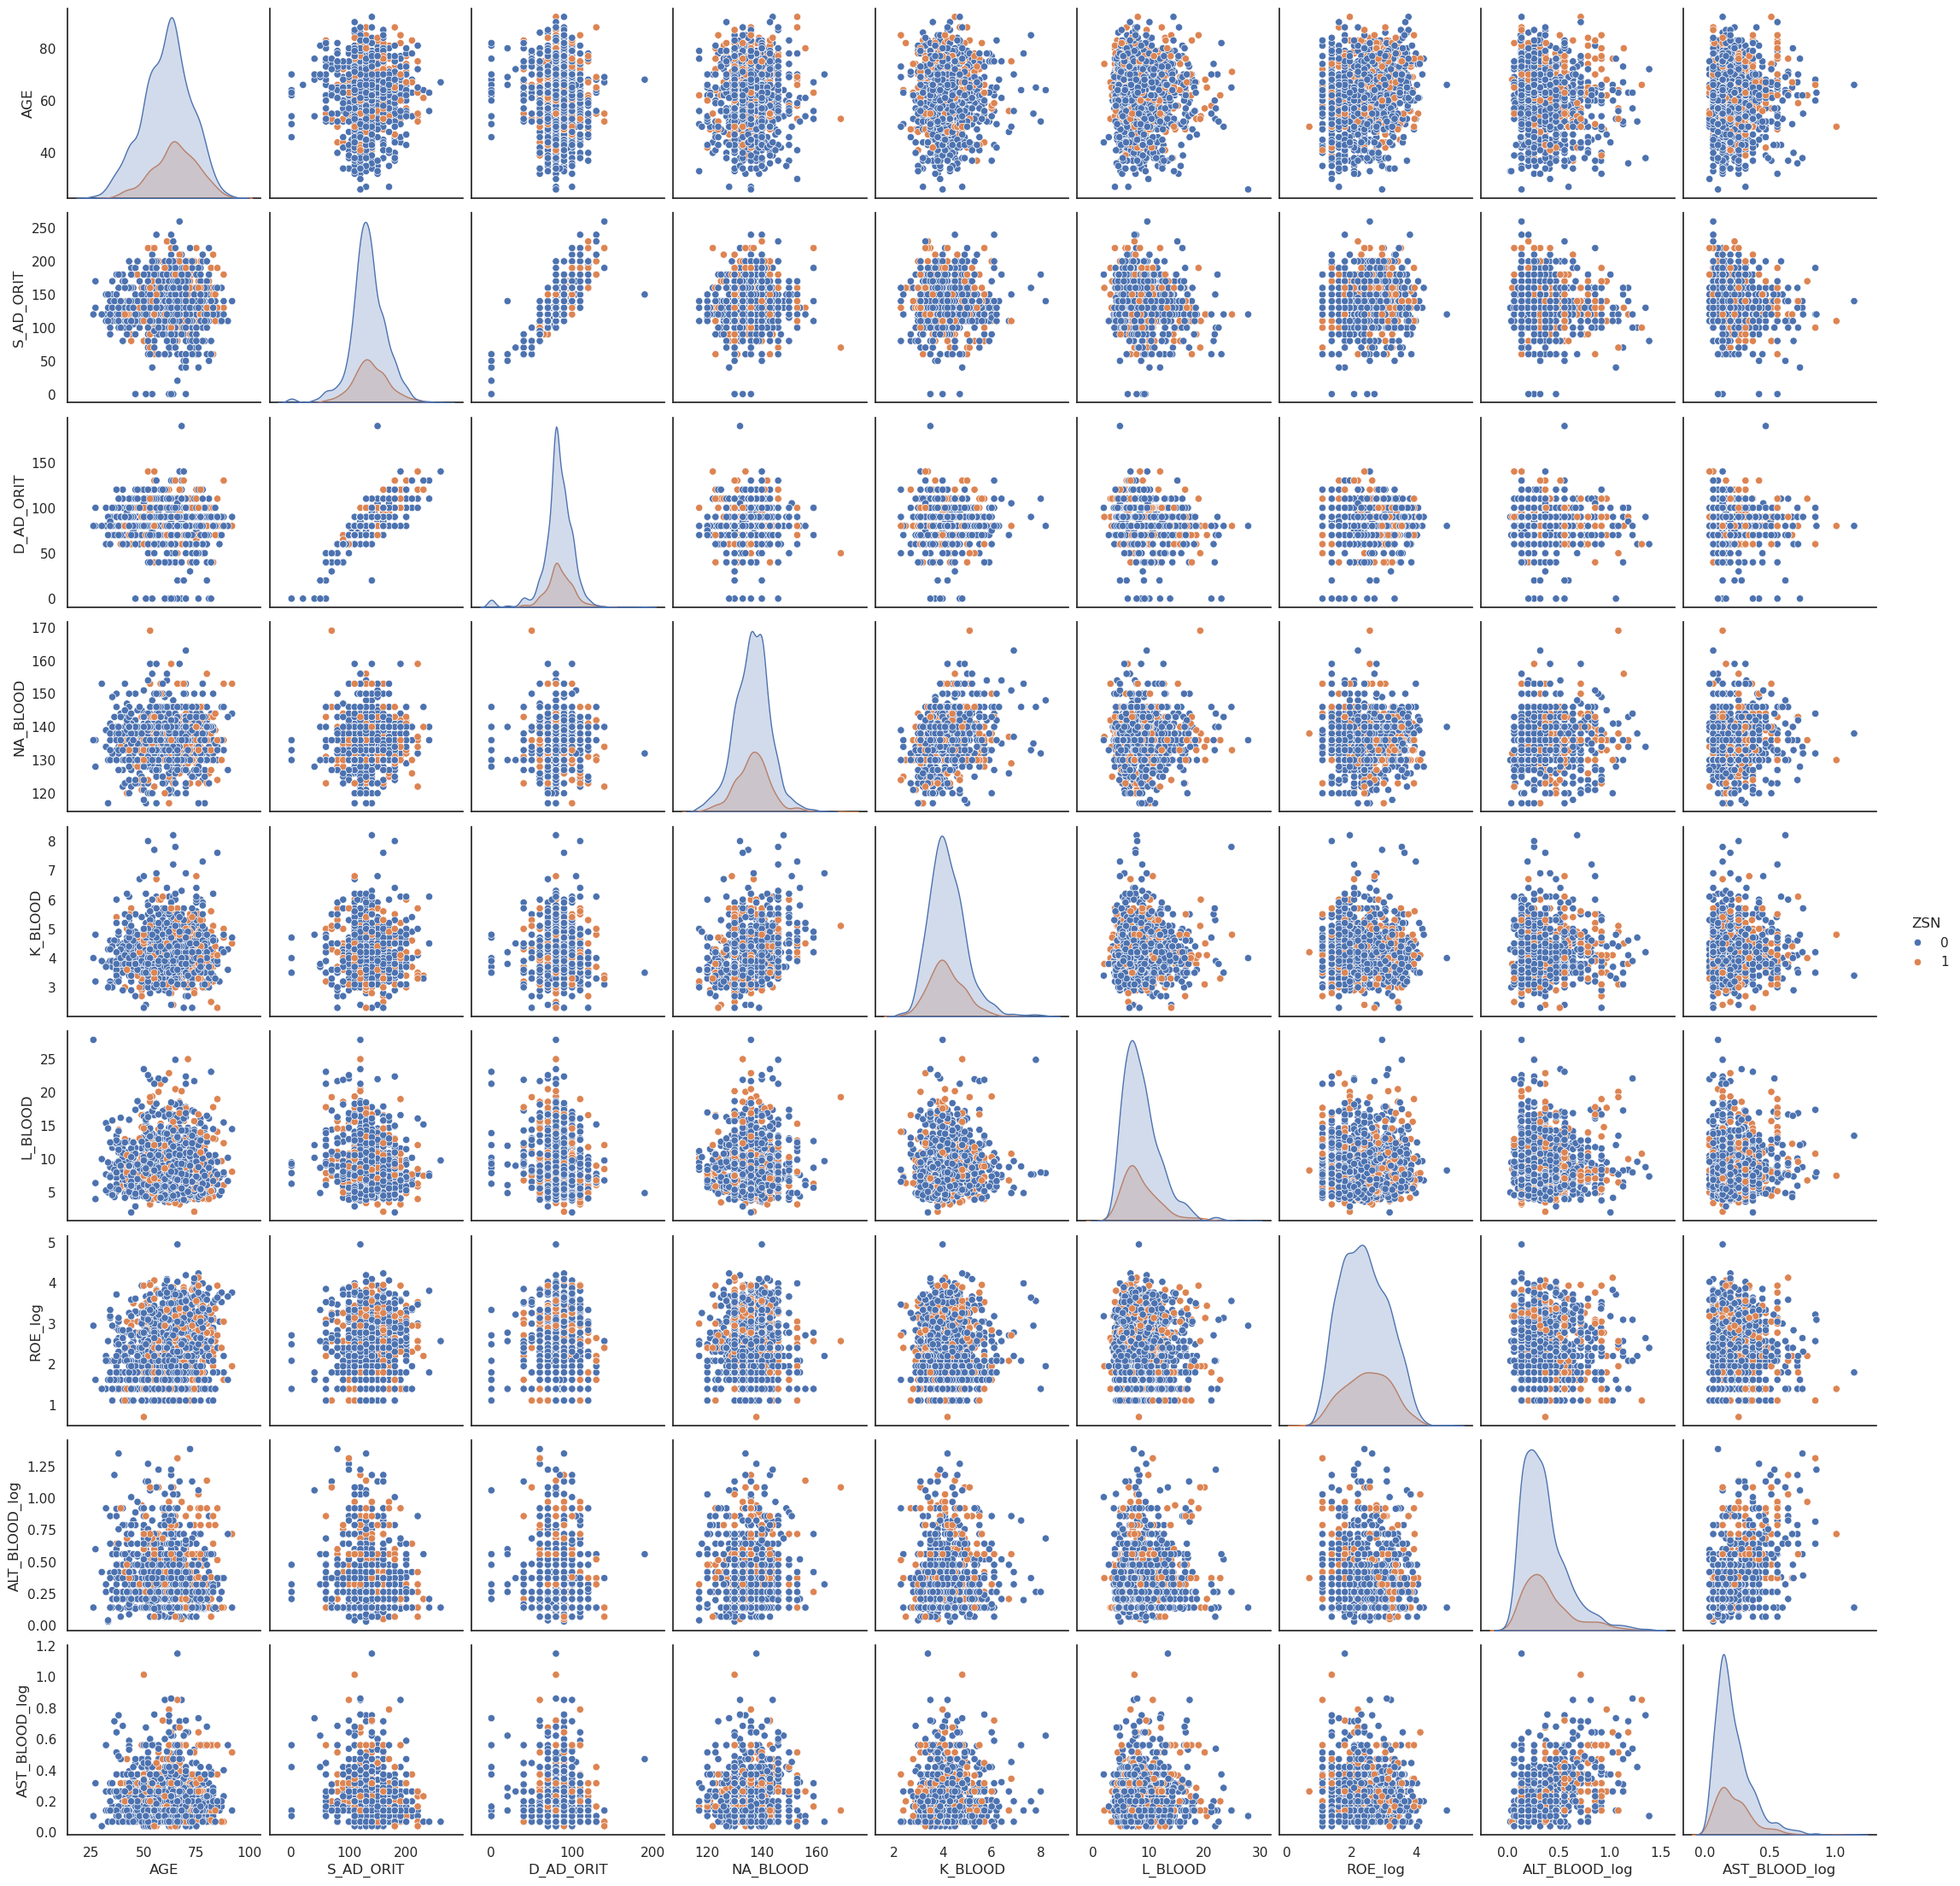

In [29]:
num_cols = [
    "AGE", "S_AD_ORIT", "D_AD_ORIT",
    "NA_BLOOD", "K_BLOOD",
    "L_BLOOD", "ROE_log",
    "ALT_BLOOD_log", "AST_BLOOD_log"
]

sns.pairplot(model_data3[num_cols + ["ZSN"]], hue="ZSN")

## EDA for Categorical Variables

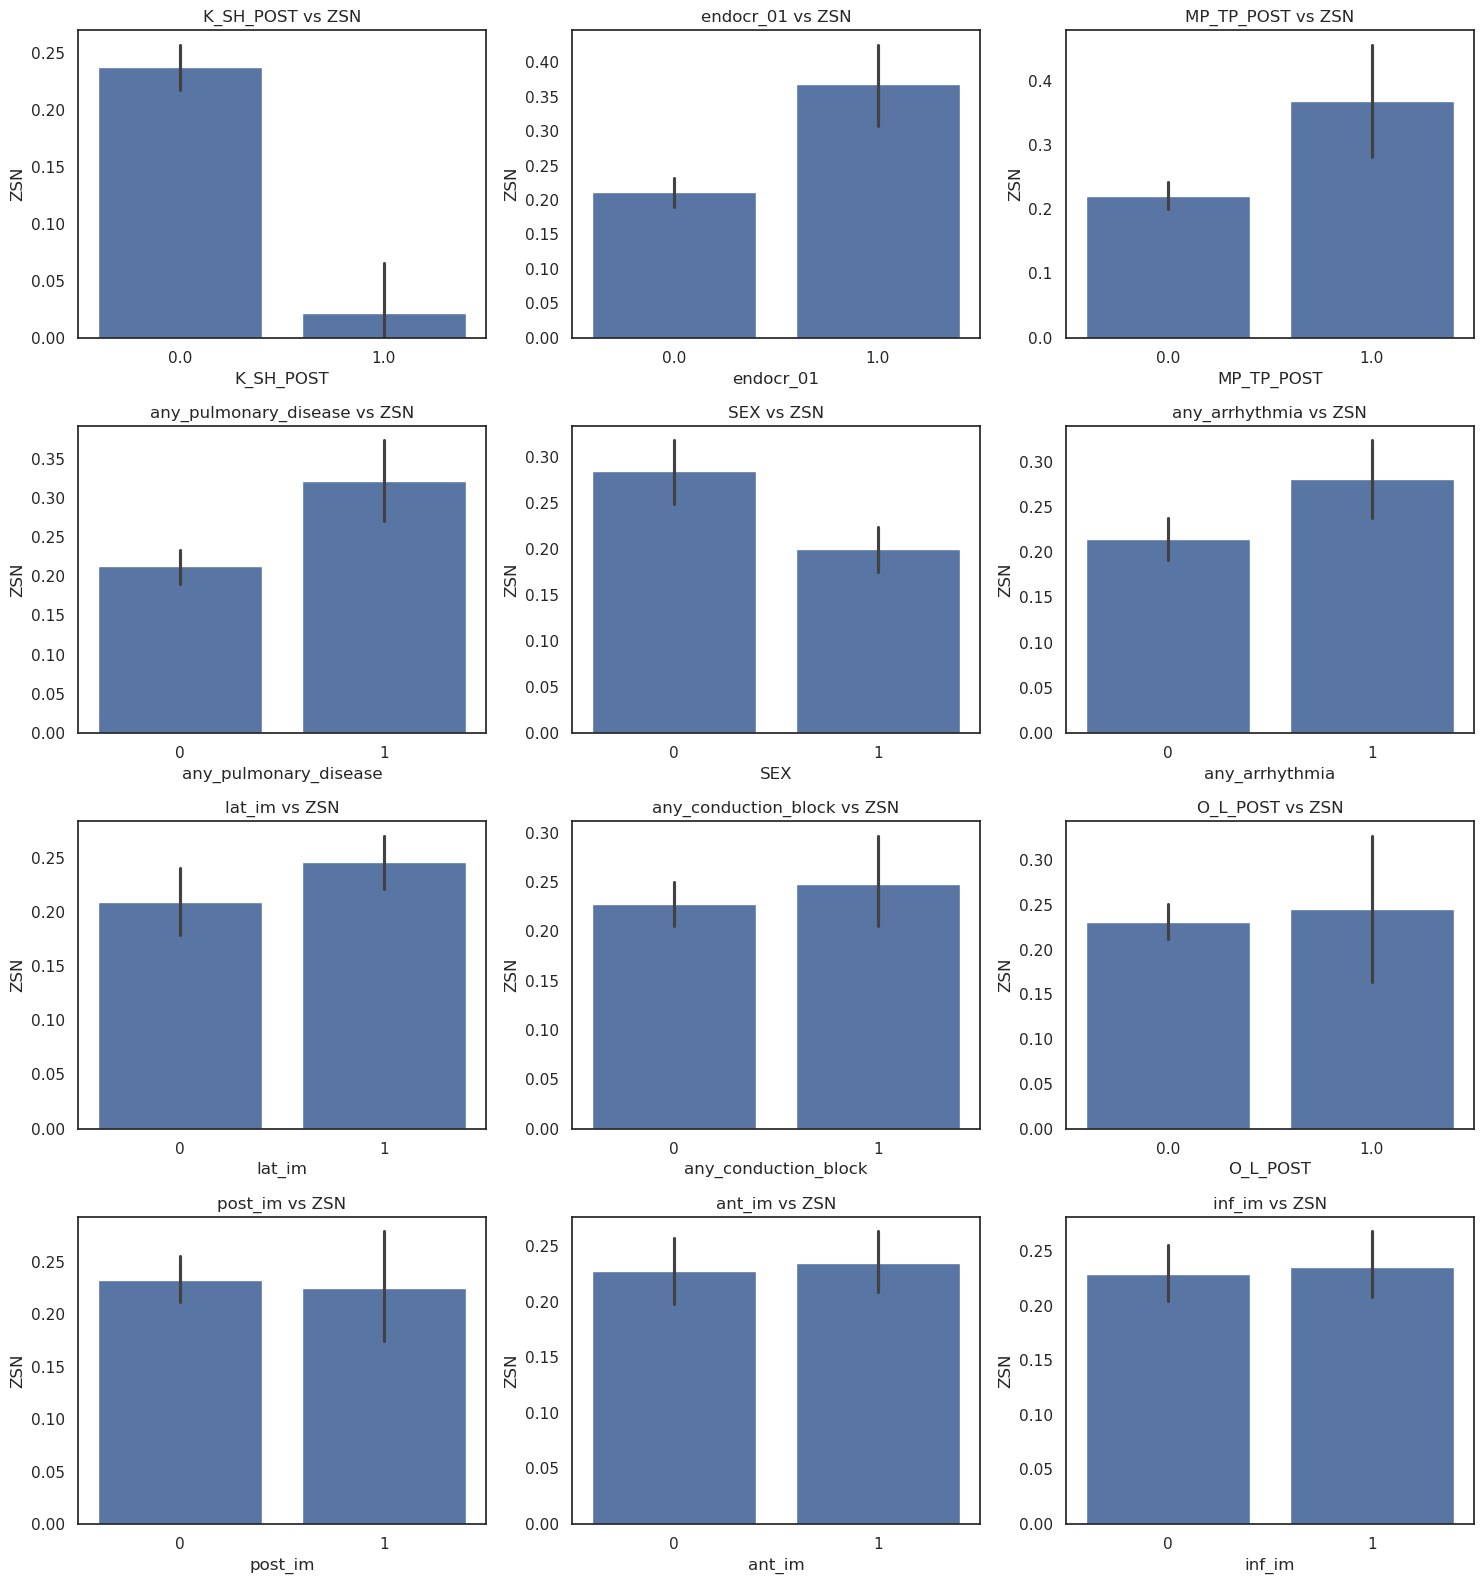

In [13]:
binary_cols = ["SEX", "endocr_01", "K_SH_POST", "O_L_POST", "MP_TP_POST",
               "ant_im", "lat_im", "inf_im", "post_im",
               "any_pulmonary_disease", "any_arrhythmia", "any_conduction_block"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

effect_size = {
    col: abs(model_data3.groupby(col)["ZSN"].mean().diff().iloc[-1])
    for col in binary_cols
}

binary_cols_sorted = sorted(effect_size, key=effect_size.get, reverse=True)

for i, col in enumerate(binary_cols_sorted):
    sns.barplot(data=model_data3, x=col, y="ZSN", ax=axes[i])
    axes[i].set_title(f"{col} vs ZSN")

plt.tight_layout()
plt.show()

Binary features such as diabetes and atrial fibrillation showed strong associations with the outcome, with expectedly higher rates of ZSN among affected patients. Pulmonary disease and arrhythmia composites demonstrated moderate effects, while some variables such as cardiogenic shock showed unstable or implausible patterns due to low prevalence.

As such, the variable K_SH_POST (cardiogenic shock) was excluded from the final model.

In [31]:
model_data3 = model_data3.drop(columns=["K_SH_POST"], errors="ignore")

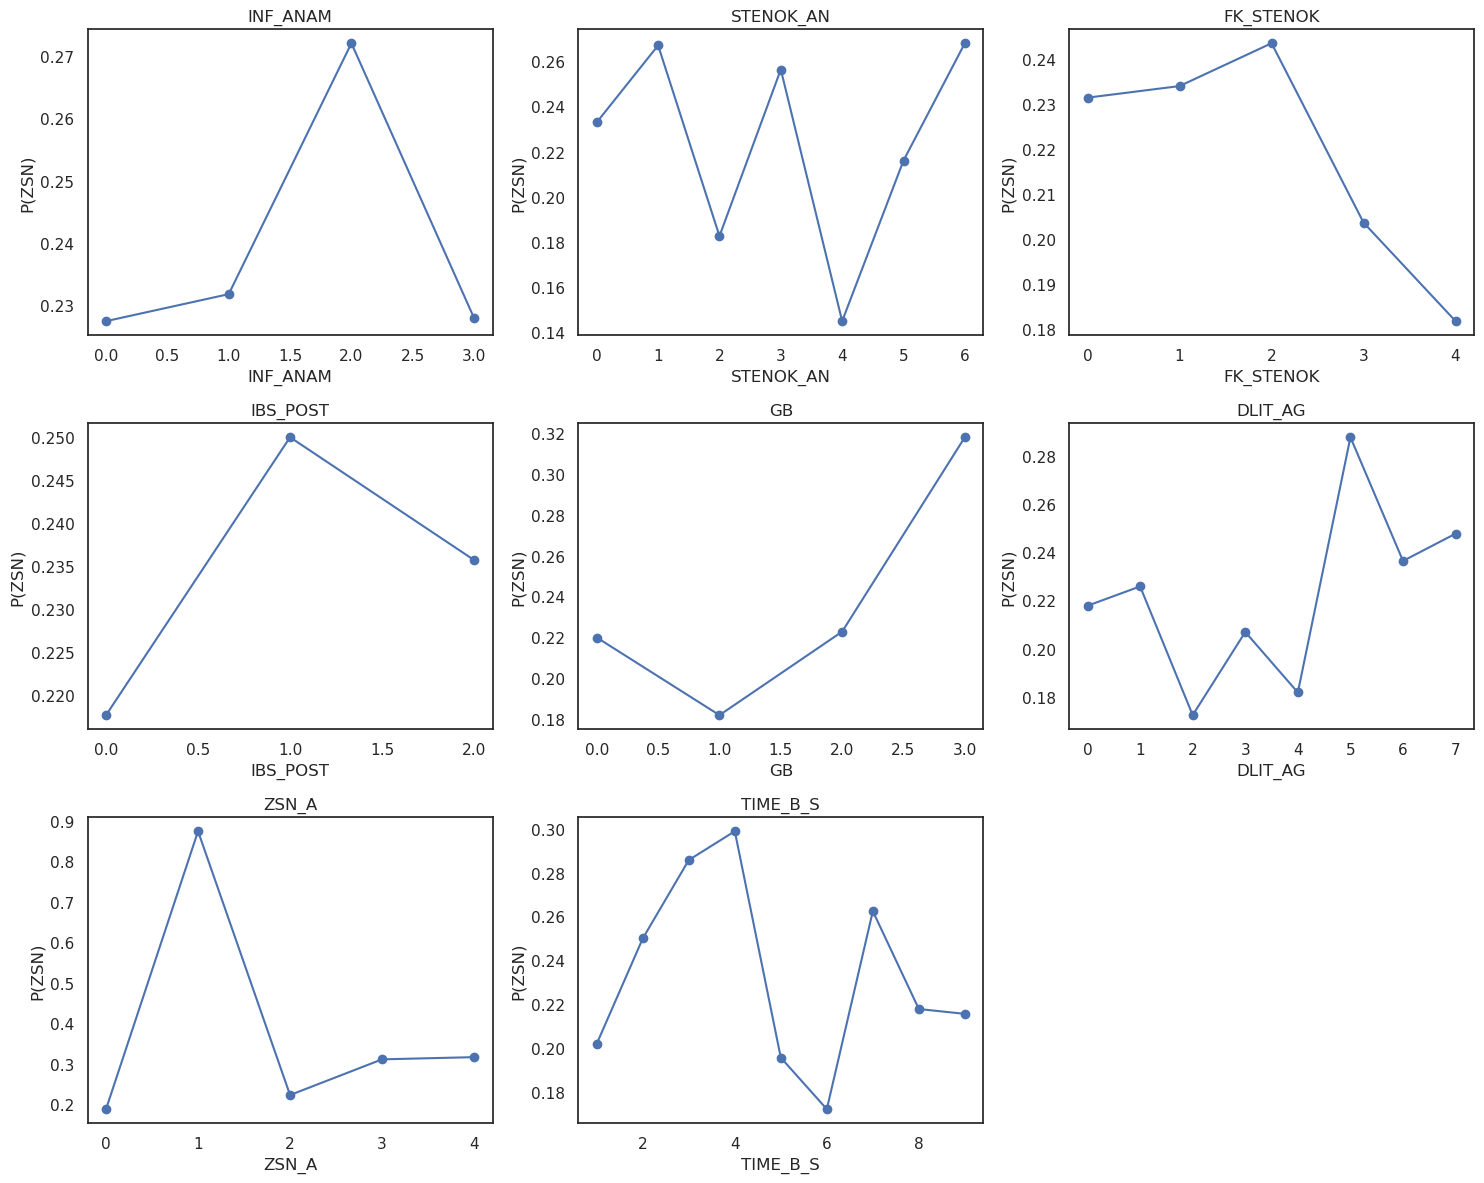

In [15]:
ordinal_cols = [
    "INF_ANAM", "STENOK_AN", "FK_STENOK", "IBS_POST", "GB",
    "DLIT_AG", "ZSN_A", "TIME_B_S"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_cols):
    means = model_data3.groupby(col)["ZSN"].mean()
    
    axes[i].plot(means.index, means.values, marker="o")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("P(ZSN)")

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# These graphs show the proportions of ZSN across different levels of the ordinal features, which can help identify trends and potential non-linear relationships. For example, if the probability of ZSN increases with higher levels of a feature, it may suggest a dose-response relationship that could be important for modeling.

* STENOK_AN is not ordinal, but a time-since-event related variable (so zig-zag pattern expected) ~ same with DLIT_AG & TIME_B_S
* FK_STENOK has high categorical imbalance ~ collapsing categories may be necessary

* ZSN_A is clearly important, but it has a Two-feature representation & extreme imbalance across categories

___

* GB, IBS_POST, INF_ANAM (drop off for 3+ category is expected) seem to function well enough as ordinal variables

In [52]:
model_data4 = model_data3.copy()

model_data4["ZSN_A_recode"] = (
    model_data4["ZSN_A"]
    .map({
        0: 0,            # none
        1: 1,            # mild
        2: 2, 3: 2, 4: 2 # moderate/severe
    })
    .astype("category")
)

# add explicit missing category
model_data4["ZSN_A_recode"] = (
    model_data4["ZSN_A_recode"]
    .cat.add_categories("missing")
    .fillna("missing")
)

def bin_time(x):
    if x in [1, 2, 3]:        # ≤6 hours
        return "early"
    elif x in [4, 5, 6]:      # 6–24 hours
        return "intermediate"
    elif x in [7, 8, 9]:      # >1 day
        return "late"
    else:
        return "missing"

model_data4["time_bin"] = model_data4["TIME_B_S"].apply(bin_time)   

def bin_stenok(x):
    if x == 0:
        return "never"
    elif x == 1:
        return "recent"        # within last year
    elif x in [2,3,4]:
        return "intermediate"  # 1–3 years
    elif x in [5,6]:
        return "remote"        # >3 years
    else:
        return "missing"

model_data4["angina_timing"] = model_data4["STENOK_AN"].apply(bin_stenok)

def bin_fk(x):
    if x == 0:
        return "none"
    elif x == 2:
        return "moderate"
    elif x in [1,3,4]:
        return "other"
    else:
        return "missing"

model_data4["angina_severity"] = model_data4["FK_STENOK"].apply(bin_fk)

def bin_dlit(x):
    if x == 0:
        return "none"
    elif x in [1,2,3]:
        return "short"        # ≤3 years
    elif x in [4,5,6]:
        return "medium"       # 4–10 years
    elif x == 7:
        return "long"         # >10 years
    else:
        return "missing"

model_data4["htn_duration"] = model_data4["DLIT_AG"].apply(bin_dlit)

# drop original variables that have been binned
model_data4 = model_data4.drop(columns=["ZSN_A", "TIME_B_S", "STENOK_AN", "FK_STENOK", "DLIT_AG"], errors="ignore")


cat_cols = [
    "time_bin", "angina_timing", "angina_severity",
    "htn_duration", "ZSN_A_recode"
]

for c in cat_cols:
    model_data4[c] = model_data4[c].astype("category")

In [53]:
model_data4.shape

final_features = model_data4.columns.drop(["ZSN", "train_dummy"]).tolist()

print(f"Number of final features: {len(final_features)}")
print(final_features)

Number of final features: 29
['AGE', 'SEX', 'INF_ANAM', 'IBS_POST', 'GB', 'endocr_01', 'S_AD_ORIT', 'D_AD_ORIT', 'O_L_POST', 'MP_TP_POST', 'NA_BLOOD', 'K_BLOOD', 'L_BLOOD', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'ritm_ecg_p_01', 'any_pulmonary_disease', 'any_arrhythmia', 'any_conduction_block', 'ROE_log', 'ALT_BLOOD_log', 'AST_BLOOD_log', 'ZSN_A_recode', 'time_bin', 'angina_timing', 'angina_severity', 'htn_duration']


In [54]:
ordinal_cols = ["INF_ANAM", "IBS_POST", "GB"]

model_data4[ordinal_cols] = model_data4[ordinal_cols].astype("Int64")

binary_cols = [
    "SEX", "endocr_01", "O_L_POST", "MP_TP_POST",
    "ant_im", "lat_im", "inf_im", "post_im",
    "ritm_ecg_p_01",
    "any_pulmonary_disease", "any_arrhythmia", "any_conduction_block"
]

model_data4[binary_cols] = model_data4[binary_cols].astype("Int64")

In [55]:
model_data4.dtypes

ZSN                         int64
train_dummy                 int64
AGE                       float64
SEX                         Int64
INF_ANAM                    Int64
IBS_POST                    Int64
GB                          Int64
endocr_01                   Int64
S_AD_ORIT                 float64
D_AD_ORIT                 float64
O_L_POST                    Int64
MP_TP_POST                  Int64
NA_BLOOD                  float64
K_BLOOD                   float64
L_BLOOD                   float64
ant_im                      Int64
lat_im                      Int64
inf_im                      Int64
post_im                     Int64
ritm_ecg_p_01               Int64
any_pulmonary_disease       Int64
any_arrhythmia              Int64
any_conduction_block        Int64
ROE_log                   float64
ALT_BLOOD_log             float64
AST_BLOOD_log             float64
ZSN_A_recode             category
time_bin                 category
angina_timing            category
angina_severit

In [56]:
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer

# start from same clean base
base = model_data4.copy()

num_cols = [
    "AGE", "S_AD_ORIT", "D_AD_ORIT",
    "NA_BLOOD", "K_BLOOD", "L_BLOOD",
    "ROE_log", "ALT_BLOOD_log", "AST_BLOOD_log"
]

binary_cols = [
    "SEX", "endocr_01", "O_L_POST", "MP_TP_POST",
    "ant_im", "lat_im", "inf_im", "post_im",
    "ritm_ecg_p_01",
    "any_pulmonary_disease", "any_arrhythmia", "any_conduction_block"
]

ordinal_cols = ["INF_ANAM", "IBS_POST", "GB"]

cat_cols = [
    "ZSN_A_recode", "time_bin", "angina_timing",
    "angina_severity", "htn_duration"
]

train_mask = base["train_dummy"] == 1

In [57]:
model_data_simple = base.copy()

# numeric
num_imp = SimpleImputer(strategy="mean")
num_imp.fit(model_data_simple.loc[train_mask, num_cols])

model_data_simple[num_cols] = num_imp.transform(model_data_simple[num_cols])

# binary + ordinal
mode_cols = binary_cols + ordinal_cols
mode_imp = SimpleImputer(strategy="most_frequent")

mode_imp.fit(model_data_simple.loc[train_mask, mode_cols])
model_data_simple[mode_cols] = mode_imp.transform(model_data_simple[mode_cols])

# restore types
model_data_simple[mode_cols] = model_data_simple[mode_cols].round().astype("Int64")

In [58]:
model_data_knn = base.copy()

# numeric first (same as above)
num_imp = SimpleImputer(strategy="mean")
num_imp.fit(model_data_knn.loc[train_mask, num_cols])

model_data_knn[num_cols] = num_imp.transform(model_data_knn[num_cols])

# KNN
knn_cols = num_cols + binary_cols + ordinal_cols
knn_imp = KNNImputer(n_neighbors=5)

knn_imp.fit(model_data_knn.loc[train_mask, knn_cols])
model_data_knn[knn_cols] = knn_imp.transform(model_data_knn[knn_cols])

In [61]:
# sanity checks

print(model_data_simple.isna().sum().sum())
print(model_data_knn.isna().sum().sum())


0
0


In [ ]:
# save imputed datasets for modeling
save_dir = current_dir.parent / "Finalized_Feature_Sets"

model_data4.to_parquet(save_dir / "non-imputed_data.parquet", engine="pyarrow", index=False)
model_data_simple.to_parquet(save_dir / "model_data_simple.parquet", engine="pyarrow", index=False)
model_data_knn.to_parquet(save_dir / "model_data_knn.parquet", engine="pyarrow", index=False)